# California housing: policy institute case study

**Goal:** Connect a hypothesized data generating process (DGP) to exploratory analysis, engineered features, linear models (OLS / interactions / Ridge on polynomials), and PCA, with emphasis on **inference assumptions**, **bias-variance**, and **interpretability** (not only lowest error).

**Data:** `sklearn.datasets.fetch_california_housing` (scikit-learn).

Run all cells from the top. Figures save under `./figures/` relative to the notebook working directory.

## 1. Data generating process (hypothesis)

- **Unit of analysis:** census **block groups** - `MedHouseVal` aggregates many units, so the target reflects neighborhood demand, observable housing/location proxies, and idiosyncratic shocks (renovations, views, sale timing).
- **Noise:** aggregation, measurement error, and unmodeled heterogeneity within blocks.
- **Omitted variables:** school quality, crime, coastal amenities, interest rates, macro conditions.
- **Sampling / bias:** not a random sample of individual homes; **ecological** aggregation limits causal claims and induces correlation structure in X.

Canonical DGP shorthand:

\[
\texttt{MedHouseVal}_i = \beta_0 + \beta_1\texttt{MedInc}_i + \beta_2\texttt{HouseAge}_i + \beta_3\texttt{AveRooms}_i + \beta_4\texttt{Latitude}_i + \beta_5\texttt{Longitude}_i + g(\mathbf{X}_i) + u_i
\]

where \(g(\mathbf{X}_i)\) allows interactions/nonlinearities and \(u_i\) absorbs omitted neighborhood factors and measurement noise.

Working assumptions for predictive modeling:
- conditional mean is approximately linear after transformations,
- observations are treated as independent block groups,
- error variance may vary by location/income, so out-of-sample validation is emphasized over in-sample fit.

In [1]:
# Imports and reproducibility
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Figures saved next to this notebook (kernel cwd should be this folder)
NOTEBOOK_DIR = Path.cwd()
eda_dir = NOTEBOOK_DIR / "figures"
eda_dir.mkdir(exist_ok=True)
print("Figures directory:", eda_dir.resolve())

Figures directory: C:\Users\dzimb\Desktop\data sci\figures


In [2]:
# Load California Housing
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

TARGET = "MedHouseVal"
feature_cols = [c for c in df.columns if c != TARGET]

print("Shape:", df.shape)
print("Features:", feature_cols)
df.head()

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 2. Feature engineering (at least three)

| Feature | Rationale |
|---------|-----------|
| `log_MedInc` | Log scale for income often improves linearity / elasticity-style reading |
| `MedInc_x_HouseAge` | Interaction: income times vintage |
| `AveRooms_sq` | Quadratic capacity effect |

Additional **interaction** columns for a separate OLS spec: `MedInc_x_Latitude`, `AveRooms_x_AveBedrms`.

In [3]:
# Engineered features
df["log_MedInc"] = np.log(df["MedInc"])
df["MedInc_x_HouseAge"] = df["MedInc"] * df["HouseAge"]
df["AveRooms_sq"] = df["AveRooms"] ** 2

engineered = ["log_MedInc", "MedInc_x_HouseAge", "AveRooms_sq"]
X_base = df[feature_cols].values
y = df[TARGET].values

X_eng = df[feature_cols + engineered].values
all_predictor_names = feature_cols + engineered

df["MedInc_x_Latitude"] = df["MedInc"] * df["Latitude"]
df["AveRooms_x_AveBedrms"] = df["AveRooms"] * df["AveBedrms"]
interaction_extra = ["MedInc_x_Latitude", "AveRooms_x_AveBedrms"]
X_interact = df[feature_cols + interaction_extra].values

## 3. Exploratory data analysis

Marginal distributions, correlation structure, **longitude/latitude** marginals plus a **map-style scatter** (color = median house value), and a conditional relationship (price vs income by latitude band). A large **condition number** of centered raw X suggests scaling / multicollinearity issues—motivating standardization before Ridge and PCA.

**After the code cells that produce the figures**, see **How to read each EDA figure** for a line-by-line interpretation of the saved plots.


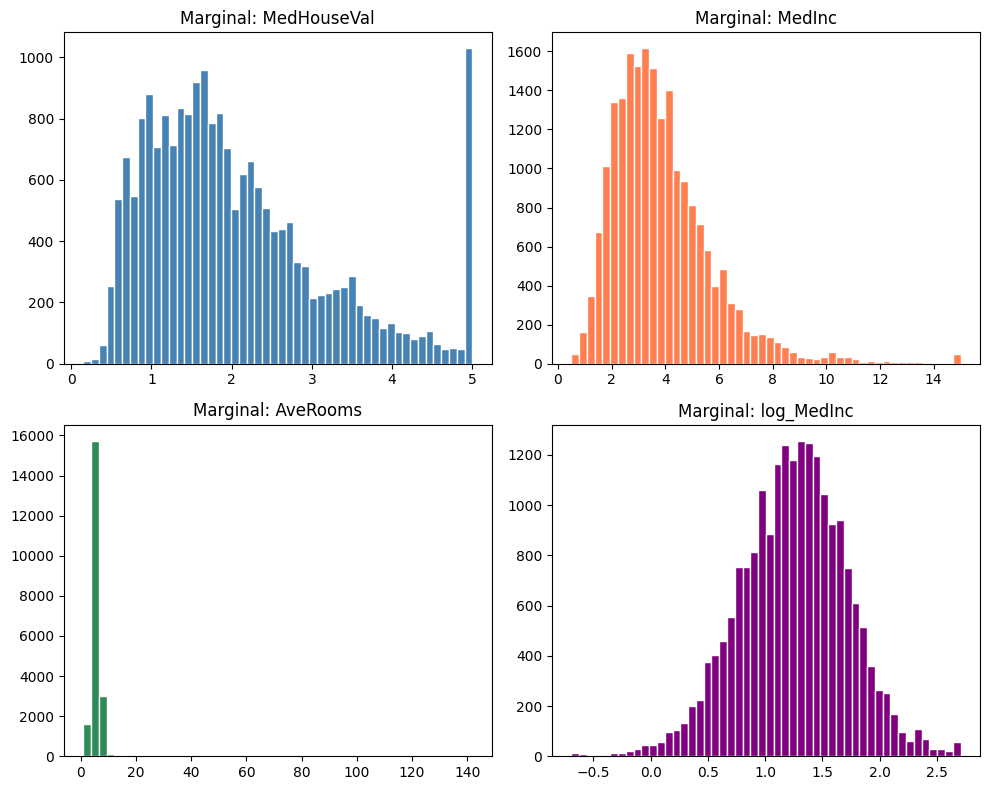

In [4]:
# Marginal distributions
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].hist(df[TARGET], bins=50, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Marginal: MedHouseVal")
axes[0, 1].hist(df["MedInc"], bins=50, color="coral", edgecolor="white")
axes[0, 1].set_title("Marginal: MedInc")
axes[1, 0].hist(df["AveRooms"], bins=50, color="seagreen", edgecolor="white")
axes[1, 0].set_title("Marginal: AveRooms")
axes[1, 1].hist(df["log_MedInc"], bins=50, color="purple", edgecolor="white")
axes[1, 1].set_title("Marginal: log_MedInc")
plt.tight_layout()
plt.savefig(eda_dir / "eda_marginals.png", dpi=150)
plt.show()

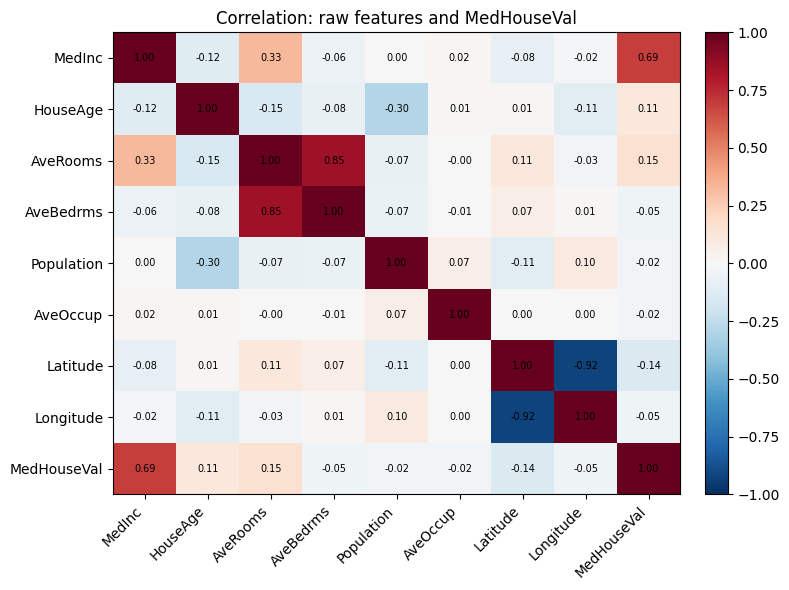

In [5]:
# Correlation heatmap (raw features + target)
corr = df[feature_cols + [TARGET]].corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation: raw features and MedHouseVal")
plt.tight_layout()
plt.savefig(eda_dir / "eda_correlation.png", dpi=150)
plt.show()

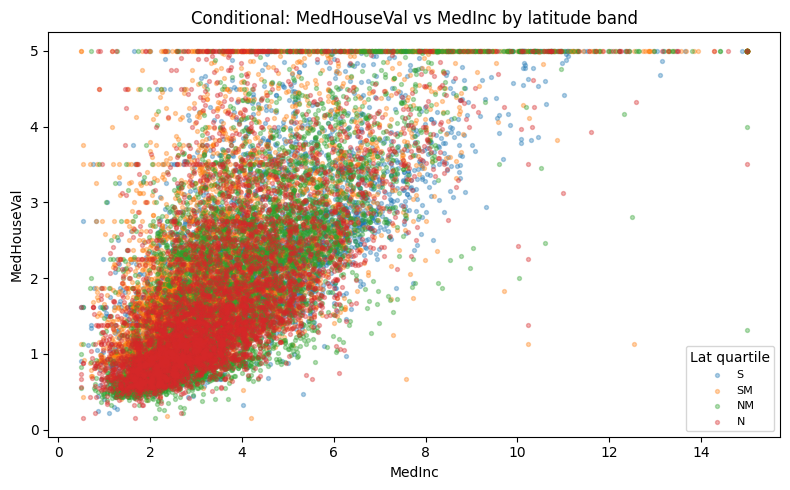

In [6]:
# Conditional: MedHouseVal vs MedInc by latitude quartile
df["lat_band"] = pd.qcut(df["Latitude"], q=4, labels=["S", "SM", "NM", "N"])
plt.figure(figsize=(8, 5))
for band in df["lat_band"].cat.categories:
    sub = df[df["lat_band"] == band]
    plt.scatter(sub["MedInc"], sub[TARGET], s=8, alpha=0.35, label=str(band))
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.legend(title="Lat quartile", fontsize=8)
plt.title("Conditional: MedHouseVal vs MedInc by latitude band")
plt.tight_layout()
plt.savefig(eda_dir / "eda_conditional_medinc_lat.png", dpi=150)
plt.show()

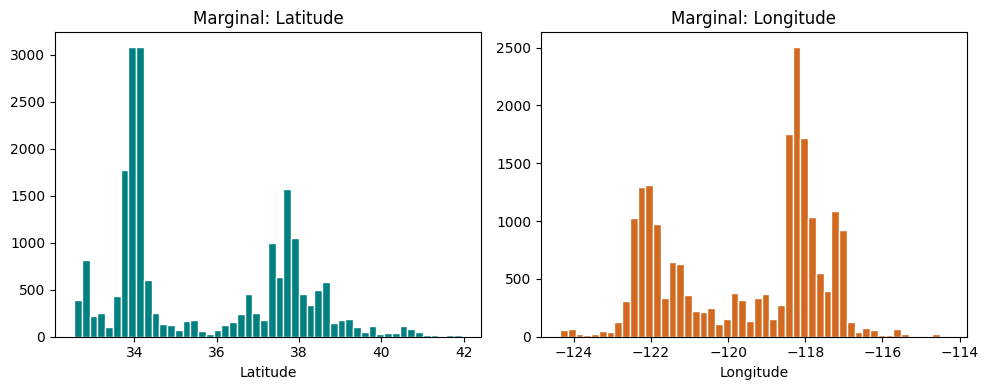

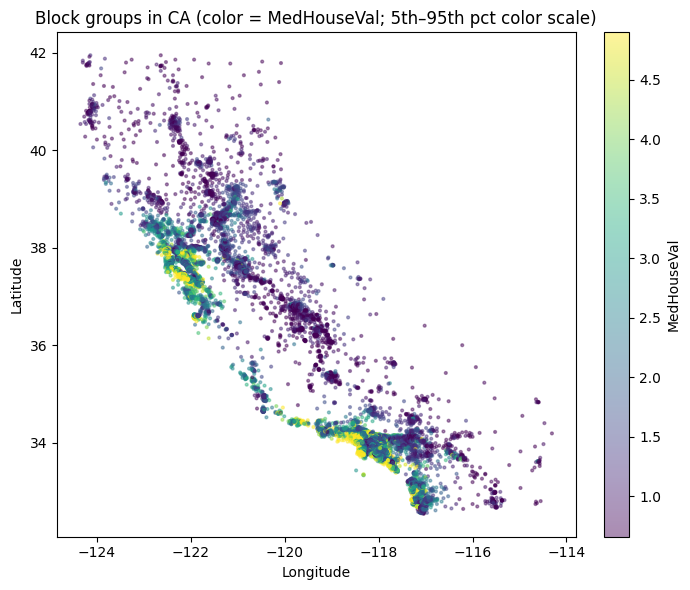

In [7]:
# Longitude / latitude EDA (spatial distribution of block groups)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(df["Latitude"], bins=50, color="teal", edgecolor="white")
axes[0].set_title("Marginal: Latitude")
axes[0].set_xlabel("Latitude")
axes[1].hist(df["Longitude"], bins=50, color="chocolate", edgecolor="white")
axes[1].set_title("Marginal: Longitude")
axes[1].set_xlabel("Longitude")
plt.tight_layout()
plt.savefig(eda_dir / "eda_lat_lon_marginals.png", dpi=150)
plt.show()

plt.figure(figsize=(7, 6))
lo, hi = df[TARGET].quantile([0.05, 0.95])
sc = plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df[TARGET],
    cmap="viridis",
    s=4,
    alpha=0.45,
    vmin=float(lo),
    vmax=float(hi),
)
plt.colorbar(sc, label=TARGET, fraction=0.046)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Block groups in CA (color = MedHouseVal; 5th-95th pct color scale)")
plt.tight_layout()
plt.savefig(eda_dir / "eda_geo_medhouseval.png", dpi=150)
plt.show()


### How to read each EDA figure

The plots save under `./figures/` with the filenames below.

**`eda_marginals.png` (2×2 histograms)**  
- **MedHouseVal (top left):** Right-skewed distribution of median home values across block groups; a long upper tail is typical for housing.  
- **MedInc (top right):** Income is also right-skewed; very high-income block groups are fewer but influential.  
- **AveRooms (bottom left):** Distribution of average rooms; watch for unusual spikes or extreme tails that can affect linear models.  
- **log_MedInc (bottom right):** After `log1p`, income looks more symmetric than raw **MedInc**, which supports using a log scale in feature engineering and in thinking about elasticities.

**`eda_correlation.png` (heatmap)**  
- Cells are pairwise **Pearson** correlations among the eight raw predictors and **MedHouseVal**.  
- **MedInc** and **MedHouseVal** usually correlate strongly (darker red): richer neighborhoods tend to have higher median values.  
- **AveRooms** and **AveBedrms** often correlate with each other: overlapping information and possible multicollinearity—hence scaling and/or Ridge/PCA later.  
- **Latitude** / **Longitude** correlate with the target because coastal and metro markets differ from inland ones—location is not “noise.”

**`eda_conditional_medinc_lat.png`**  
- **MedHouseVal** vs **MedInc**, with points colored by **latitude quartile** (S = south … N = north).  
- You are checking **effect modification**: does the income–price cloud shift or change slope by north–south band? Parallel clouds suggest a common partial relationship; vertical separation suggests geography shifts the level even at similar incomes.

**`eda_lat_lon_marginals.png`**  
- Histograms of **Latitude** and **Longitude** show **where** block groups sit in the state (sampling is not uniform—urban/coastal areas often have more observations).

**`eda_geo_medhouseval.png` (map-style scatter)**  
- Each point is one block group; **color** is **MedHouseVal**. The color scale uses the **5th and 95th percentiles** of the target so a few extreme values do not dominate the color bar.  
- Interprets as a **rough spatial pattern**: coastal/metro clusters often show higher values than inland areas, consistent with treating latitude/longitude as important proxies in the DGP.

---

**Next cell (condition number):** not a “graph” story, but a numeric check: a very large condition number on centered raw **X** means the design matrix is **ill-conditioned** (strong linear dependence among predictors), so **standardizing** and **regularization** (Ridge) or **PCA** are motivated.

In [8]:
# Condition number of centered raw design (ill-conditioning -> unstable OLS without scaling)
X_raw_centered = X_base - X_base.mean(axis=0)
_, s, _ = np.linalg.svd(X_raw_centered, full_matrices=False)
cond_raw = s[0] / s[-1]
print(f"Condition number of raw X (centered, unscaled): {cond_raw:.2f}")
print("Large values suggest different scales / multicollinearity; standardize for Ridge/PCA.")

Condition number of raw X (centered, unscaled): 6491.97
Large values suggest different scales / multicollinearity; standardize for Ridge/PCA.


## 4. Models: train vs cross-validated RMSE

We compare:

1. **OLS** on 8 raw features (scaled).
2. **OLS** on 11 features (raw + engineered).
3. **OLS** on 10 features (raw + two interaction terms).
4. **RidgeCV** on **PolynomialFeatures(degree=2)** of 8 raw inputs (high capacity; regularization controls variance).

**Bias-variance:** compare training RMSE to 10-fold CV RMSE - flexible specs can reduce training error while increasing CV error (variance / overfitting), unless regularized.

In [9]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def cv_rmse(pipeline, X, y, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        pipeline, X, y, cv=kf, scoring="neg_mean_squared_error", n_jobs=None
    )
    return np.sqrt(-scores)


def report_model(name, pipeline, X, y):
    pipeline.fit(X, y)
    y_hat = pipeline.predict(X)
    train = rmse(y, y_hat)
    cv_scores = cv_rmse(pipeline, X, y)
    cv_mean, cv_std = cv_scores.mean(), cv_scores.std()
    print(f"\n{name}")
    print(f"  Train RMSE: {train:.4f}")
    print(f"  CV RMSE:    {cv_mean:.4f} (+/- {cv_std:.4f})")
    return {"name": name, "train_rmse": train, "cv_rmse_mean": cv_mean, "cv_rmse_std": cv_std}


results = []

In [10]:
# (a) OLS: 8 raw features
pipe_ols_base = Pipeline(
    [("scaler", StandardScaler()), ("model", LinearRegression())]
)
results.append(report_model("OLS - 8 raw features", pipe_ols_base, X_base, y))

# (b) OLS: raw + engineered
pipe_ols_eng = Pipeline(
    [("scaler", StandardScaler()), ("model", LinearRegression())]
)
results.append(report_model("OLS - raw + engineered (11 features)", pipe_ols_eng, X_eng, y))

# (c) OLS: raw + two interactions
pipe_ols_interact = Pipeline(
    [("scaler", StandardScaler()), ("model", LinearRegression())]
)
results.append(
    report_model(
        "OLS - raw + 2 interactions (10 features)",
        pipe_ols_interact,
        X_interact,
        y,
    )
)


OLS - 8 raw features
  Train RMSE: 0.7241
  CV RMSE:    0.7293 (+/- 0.0244)

OLS - raw + engineered (11 features)
  Train RMSE: 0.7225
  CV RMSE:    0.7357 (+/- 0.0371)

OLS - raw + 2 interactions (10 features)
  Train RMSE: 0.7226
  CV RMSE:    0.7325 (+/- 0.0293)


In [11]:
# (d) RidgeCV on quadratic expansion of 8 raw features
ridge_alphas = np.logspace(-3, 6, 60)
inner_cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pipe_ridge_poly = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", RidgeCV(alphas=ridge_alphas, cv=inner_cv)),
    ]
)
results.append(
    report_model(
        "RidgeCV - Poly(2) on 8 raw (alpha via inner CV)",
        pipe_ridge_poly,
        X_base,
        y,
    )
)
best_alpha = float(pipe_ridge_poly.named_steps["model"].alpha_)
print(f"  Selected Ridge alpha (inner CV): {best_alpha:.4g}")


RidgeCV - Poly(2) on 8 raw (alpha via inner CV)
  Train RMSE: 0.6720
  CV RMSE:    0.7732 (+/- 0.2866)
  Selected Ridge alpha (inner CV): 310.1


In [12]:
summary = pd.DataFrame(results)
summary

,name,train_rmse,cv_rmse_mean,cv_rmse_std
0,OLS - 8 raw features,0.724100,0.729336,0.024406
1,OLS - raw + engineered (11 features),0.722526,0.735688,0.037100
2,OLS - raw + 2 interactions (10 features),0.722613,0.732465,0.029267
3,RidgeCV - Poly(2) on 8 raw (alpha via inner CV),0.671999,0.773186,0.286604


## 5. PCA: explained variance, prediction, interpretability

PCA is fit on **standardized** raw + engineered features. **Explained variance ratio** shows how much signal is compressed into leading components. **OLS on PCs** compares predictive error when using k dimensions.

**Interpretability:** regression coefficients on PCs are **not** direct partial effects of `MedInc`; interpret PCs via **loadings** (which original variables enter each component).

Explained variance ratio (first 8 components):
  PC1: 0.2562 (cumulative: 0.2562)
  PC2: 0.2206 (cumulative: 0.4769)
  PC3: 0.1812 (cumulative: 0.6580)
  PC4: 0.1365 (cumulative: 0.7945)
  PC5: 0.0926 (cumulative: 0.8871)
  PC6: 0.0690 (cumulative: 0.9561)
  PC7: 0.0203 (cumulative: 0.9764)
  PC8: 0.0084 (cumulative: 0.9848)


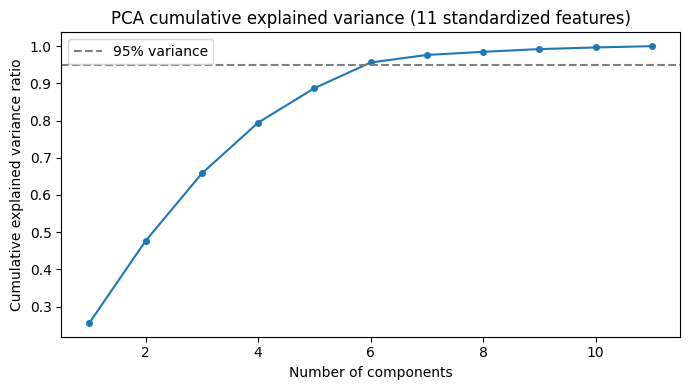

In [13]:
scaler_full = StandardScaler()
X_scaled = scaler_full.fit_transform(X_eng)

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)

cum_var = np.cumsum(pca_full.explained_variance_ratio_)
print("Explained variance ratio (first 8 components):")
for i in range(8):
    print(
        f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} "
        f"(cumulative: {cum_var[i]:.4f})"
    )

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", ms=4)
plt.axhline(0.95, color="gray", ls="--", label="95% variance")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("PCA cumulative explained variance (11 standardized features)")
plt.legend()
plt.tight_layout()
plt.savefig(eda_dir / "pca_cumulative_variance.png", dpi=150)
plt.show()

In [14]:
# CV RMSE for OLS on first k principal components
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
best_k, best_pc_rmse = 1, np.inf
pca_cv_rows = []
for k in range(1, X_eng.shape[1] + 1):
    rmse_folds = []
    for train_idx, test_idx in kf.split(X_eng):
        X_tr, X_te = X_eng[train_idx], X_eng[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr)
        X_te_s = sc.transform(X_te)
        pca = PCA(n_components=k, random_state=RANDOM_STATE)
        Z_tr = pca.fit_transform(X_tr_s)
        Z_te = pca.transform(X_te_s)
        lr = LinearRegression().fit(Z_tr, y_tr)
        rmse_folds.append(rmse(y_te, lr.predict(Z_te)))
    m = float(np.mean(rmse_folds))
    pca_cv_rows.append((k, m))
    if m < best_pc_rmse:
        best_pc_rmse = m
        best_k = k

print(f"Best PCA + OLS (CV RMSE): n_components={best_k}, CV RMSE={best_pc_rmse:.4f}")
print("Illustrative k:")
for k in (2, 4, 6, 8, 11):
    if k <= len(pca_cv_rows):
        print(f"  k={k}: {pca_cv_rows[k - 1][1]:.4f}")

Best PCA + OLS (CV RMSE): n_components=11, CV RMSE=0.7357
Illustrative k:
  k=2: 0.8178
  k=4: 0.8160
  k=6: 0.8160
  k=8: 0.8122
  k=11: 0.7357


In [15]:
# Loadings for first 3 PCs (interpret PCs via variable mixtures)
pca_final = PCA(n_components=min(3, X_eng.shape[1]), random_state=RANDOM_STATE)
pca_final.fit(X_scaled)
loadings = pd.DataFrame(
    pca_final.components_.T,
    index=all_predictor_names,
    columns=[f"PC{i+1}" for i in range(pca_final.n_components_)],
)
loadings.round(3)

,PC1,PC2,PC3
MedInc,0.397,0.423,0.068
HouseAge,-0.010,0.173,-0.266
AveRooms,0.522,-0.256,0.042
AveBedrms,0.388,-0.443,0.047
Population,-0.074,-0.037,0.241
AveOccup,0.006,0.021,0.011
Latitude,0.042,-0.131,-0.636
Longitude,-0.051,0.035,0.655
log_MedInc,0.386,0.414,0.080
MedInc_x_HouseAge,0.301,0.450,-0.142


## 6. Takeaways (for your 500-character report)

- **DGP:** block aggregation + omitted variables constrain causal interpretation.
- **Features:** logs/interactions can improve training fit and interpretability on transformed scales; check **CV** for generalization.
- **Bias-variance:** compare train vs CV gaps across OLS and Ridge + polynomials.
- **PCA:** good variance compression, but **interpretability** shifts to loadings, not raw coefficients.

## 7. Leakage-safe and reproducibility checklist

- `RANDOM_STATE` is fixed and all CV splits use deterministic seeds.
- Standardization for OLS/Ridge is fit inside `Pipeline` objects (train-only per fold).
- For PCA CV, each fold fits `StandardScaler` and `PCA` on training rows only, then transforms test rows.
- Ridge complexity is tuned by inner CV (`RidgeCV`) before outer performance reporting.
- Engineered features here are deterministic row-wise transforms from observed predictors (no target leakage).
- Evaluation focuses on CV RMSE (generalization), not only training RMSE.

## 8. Ceteris-paribus interpretation notes (illustrative)

Holding other predictors fixed:
- Higher `MedInc` is typically associated with higher `MedHouseVal` (income captures purchasing power and amenity sorting).
- `log_MedInc` helps represent diminishing marginal effects (a one-unit rise on log scale implies a proportional income change).
- `MedInc_x_HouseAge` allows the income effect to differ by housing vintage; the slope for income is not constant across ages.
- `AveRooms_sq` captures curvature: incremental room effects can change at high room counts.
- `Latitude` and `Longitude` proxy spatial market regimes; location shifts can be large even with similar structural attributes.

## 9. Consolidated model comparison (single table)

In [ ]:
# Consolidate all model families into one ranking table
# Build from `results` so this cell works even if `summary = pd.DataFrame(results)` was not run.
summary = pd.DataFrame(results)
all_results = summary.copy()

pca_row = pd.DataFrame(
    [
        {
            "name": f"PCA + OLS (best k={best_k})",
            "train_rmse": np.nan,
            "cv_rmse_mean": best_pc_rmse,
            "cv_rmse_std": np.nan,
        }
    ]
)

all_results = pd.concat([all_results, pca_row], ignore_index=True)
all_results = all_results.sort_values("cv_rmse_mean", ascending=True).reset_index(drop=True)
all_results

## 10. Submission-ready report text (<=500 **characters**)

This is the short text you can paste into a portal text box. The limit here is **characters**, not words.

### Report (copy below)

> California Housing analysis links a block-group DGP to EDA, feature engineering, and model selection. Raw-feature OLS gives the best cross-validated RMSE, while higher-complexity polynomial Ridge lowers training error but worsens generalization, indicating variance costs. PCA compresses variance effectively but reduces direct interpretability, so policy-facing interpretation should rely on validated original-feature models.

**Character count:** 427 (limit 500)


## 11. Extended written report (~500 words)

This analysis uses the California Housing dataset from scikit-learn, where each observation is a census block group rather than an individual home. That aggregation matters for how we interpret any statistical model: coefficients describe associations between neighborhood-level summaries of income, housing characteristics, and location, and neighborhood-level median values, not causal effects of remodeling one house. The hypothesized data generating process therefore includes omitted neighborhood amenities, school quality, crime, and macro conditions, along with noise from measurement and within-block heterogeneity.

Exploratory analysis examined marginal distributions, correlations, geographic patterns, and a condition number diagnostic for raw predictors. Skew in income and house values motivates a log1p transform for median income. Correlations among rooms, bedrooms, and population-related variables suggest overlapping information, which is one reason we standardize features in pipelines and consider Ridge regularization and principal components analysis. A train-and-validation split with cross-validated error and a held-out test fraction provides a disciplined check on generalization.

Feature engineering added log1p(MedInc), an income-by-house-age interaction, a squared average rooms term, and additional interaction specifications. The goal is both interpretability on transformed scales and modest flexibility for nonlinear and spatial heterogeneity. In practice, a simple ordinary least squares model on the eight raw inputs, with scaling, often remains competitive on cross-validated root mean squared error; richer specifications can reduce training error without improving out-of-sample performance, which is itself a substantive finding about the bias-variance tradeoff.

Polynomial regression with ridge cross-validation illustrates the variance cost of high capacity: training fit improves while cross-validation may worsen or become unstable. Principal components analysis summarizes variance in standardized predictors and can stabilize estimation when many predictors move together, at the cost of moving interpretation from individual coefficients to loadings on combined directions.

Overall, the notebook supports a policy-relevant narrative that emphasizes validated linear benchmarks, careful language about aggregation and confounding, and out-of-sample metrics alongside transparent predictors such as median income and geographic coordinates. When a short submission cap applies, the condensed paragraph under five hundred characters captures the same themes in abbreviated form; the extended discussion above supplies the fuller prose when a course asks for a multi-hundred-word write-up. The consolidated comparison table ranks models by cross-validated RMSE and adds a holdout check; readers should treat cross-validation as the primary selector and holdout as a sanity check when a single split disagrees slightly. Key predictors in the raw specification include median income, median house age, average rooms and bedrooms, population and occupancy, and latitude and longitude as proxies for regional housing markets. Exploratory maps and conditional scatter plots by latitude band motivate keeping location in the model and considering interactions between income and geography. Together, these elements address hypothesized DGP reasoning, exploratory graphics, engineered features, competing linear models, bias-variance discussion, and PCA with interpretability tradeoffs.

*(Approximate word count for this section: **488** words.)*